In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.dirname(os.getcwd()))
from lib.utils import get_sequence_data
from lib.BLogistic import SkewedBLogistic, train_blogistic

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

folder_path = r"../../MarketData/historical_data"
context_window = 60
X, Y = get_sequence_data(folder_path, context_window, force_recompute=True)
dof = 16
simple_X = torch.tensor(X[:, :, 0], device=device)
simple_Y = torch.tensor(Y, device=device).reshape(-1, 1)

dev_size = 10000
np.random.seed(0)
indices = np.random.permutation(simple_X.shape[0])

dev_indices = indices[:dev_size]
train_indices = indices[dev_size:]
train_X = simple_X[train_indices]
train_Y = simple_Y[train_indices]
dev_X = simple_X[dev_indices, :]
dev_Y = simple_Y[dev_indices]

std = train_Y.std()
train_X = train_X / std
train_Y = train_Y / std
dev_X = dev_X / std
dev_Y = dev_Y / std
print("train_X", train_X.shape, "train_Y", train_Y.shape, "dev_X", dev_X.shape, "dev_Y", dev_Y.shape)
print("std", std, train_X.std())

../../MarketData/historical_data
1256
skipping 2020-11-27
skipping 2020-12-24
skipping 2021-11-26
skipping 2022-11-25
skipping 2023-07-03
skipping 2023-11-24
skipping 2024-07-03
skipping 2024-11-29
skipping 2024-12-24
skipping 2025-07-03
train_X torch.Size([402426, 60]) train_Y torch.Size([402426, 1]) dev_X torch.Size([10000, 60]) dev_Y torch.Size([10000, 1])
std tensor(0.0004, device='cuda:0') tensor(1.0232, device='cuda:0')


In [5]:

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(context_window, context_window)
        self.fc2 = nn.Linear(context_window, dof)
        with torch.no_grad():
            self.fc1.weight *= 0.01
            self.fc2.weight *= 0.01
            self.fc1.bias *= 0
            self.fc2.bias *= 0
        self.blogistic = SkewedBLogistic(dof - 3, device=device)

    def forward(self, x, y):
        layer1 = torch.relu(self.fc1(x))
        params = self.fc2(layer1)
        return -self.blogistic.logpdf_vectorized(y, params[:, :-2], params[:, -2], params[:, -1]).mean()

    def print_nan_params(self, x, y):
        layer1 = torch.relu(self.fc1(x))
        params = self.fc2(layer1)
        where_nan = params.isnan().any(dim=1)
        print("where_nan", where_nan.shape)
        if where_nan.any():
            print("params", params[where_nan, :-2])
            print("params", params[where_nan, -2])
            print("params", params[where_nan, -1])

    def get_params(self, x):
        layer1 = torch.relu(self.fc1(x))
        params = self.fc2(layer1)
        return params

    def get_logpdf(self, x, sample_xs):
        params = self.get_params(x)
        return self.blogistic.logpdf(sample_xs, params[:, :-2].flatten(), params[:, -2], params[:, -1])

    def get_pdf(self, x, sample_xs):
        return torch.exp(self.get_logpdf(x, sample_xs))

def train_simple_nn(train_X, train_Y, dev_X, dev_Y, lr, num_steps, device: torch.device = None, transfer_learn = True):
    model = SimpleNN().to(device)
    if transfer_learn:
        iid_train_steps = 500
        iid_lr = 0.05
        _, offset = train_blogistic(train_Y.flatten(), dof, iid_lr, iid_train_steps, allow_skew=True, device=device)
        with torch.no_grad():
            model.fc2.bias[:-2].copy_(offset[0])
            model.fc2.bias[-2].copy_(offset[1])
            model.fc2.bias[-1].copy_(offset[2])
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    batch_size = train_X.shape[0]
    print("num batches", train_X.shape[0] // batch_size)
    train_losses = []
    dev_losses = []
    for step in range(num_steps):
        # run mini-batch training
        for i in range(0, train_X.shape[0], batch_size):
            batch_X = train_X[i:i+batch_size, :]
            batch_Y = train_Y[i:i+batch_size, :]
            loss = model(batch_X, batch_Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if step % 100 == 0:
            train_loss = model(train_X, train_Y)
            dev_loss = model(dev_X, dev_Y)
            train_losses.append(train_loss.item())
            dev_losses.append(dev_loss.item())

            print(f"Step {step}, Train Loss: {train_loss.item():.4f}, Dev Loss: {dev_loss.item():.4f}")
    return model, train_losses, dev_losses


Step 100, Loss: 1.2517
Step 200, Loss: 1.2507
Step 300, Loss: 1.2502
Step 400, Loss: 1.2499
Step 500, Loss: 1.2497
Step 500, Final Loss: 1.2497
num batches 1
Step 0, Train Loss: 1.2496, Dev Loss: 1.2497
Step 100, Train Loss: 1.1595, Dev Loss: 1.1655
Step 200, Train Loss: 1.1340, Dev Loss: 1.1443
Step 300, Train Loss: 1.1188, Dev Loss: 1.1312
Step 400, Train Loss: 1.1085, Dev Loss: 1.1228
Step 500, Train Loss: 1.1010, Dev Loss: 1.1171
Step 600, Train Loss: 1.0947, Dev Loss: 1.1115
Step 700, Train Loss: 1.0891, Dev Loss: 1.1072
Step 800, Train Loss: 1.0841, Dev Loss: 1.1017
Step 900, Train Loss: 1.0814, Dev Loss: 1.1007
Step 1000, Train Loss: 1.0801, Dev Loss: 1.1006
Step 1100, Train Loss: 1.0792, Dev Loss: 1.1003
Step 1200, Train Loss: 1.0786, Dev Loss: 1.1004
Step 1300, Train Loss: 1.0782, Dev Loss: 1.1004
Step 1400, Train Loss: 1.0779, Dev Loss: 1.1003
Step 1500, Train Loss: 1.0776, Dev Loss: 1.1006
Step 1600, Train Loss: 1.0775, Dev Loss: 1.1007
Step 1700, Train Loss: 1.0774, Dev Los

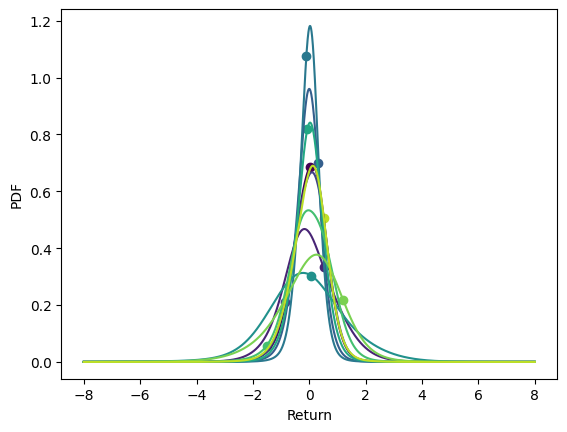

In [6]:

lr = 1e-3
num_steps = 3000
model, train_losses, dev_losses = train_simple_nn(train_X, train_Y, dev_X, dev_Y, lr, num_steps, device=device)
torch.save(model.state_dict(), f"jl_simple_nn_model_context{context_window}.pth")
model = SimpleNN().to(device)
model.load_state_dict(torch.load(f"jl_simple_nn_model_context{context_window}.pth"))

plot_xs = torch.linspace(-8, 8, 10000, device=device)
nplots = 10

for idx in range(nplots):
    # get color wheel
    color = plt.cm.viridis(idx / nplots)
    plot_ys = model.get_pdf(dev_X[idx, :].reshape(1, -1), plot_xs)
    plt.plot(plot_xs.cpu().numpy(), plot_ys.detach().cpu().numpy(), color=color)
    plt.scatter(dev_Y[idx, :].cpu().numpy(), model.get_pdf(dev_X[idx, :].reshape(1, -1), dev_Y[idx, :].reshape(1, 1)).detach().cpu().numpy(), color=color)

plt.xlabel("Return")
plt.ylabel("PDF")
plt.show()